# Valutazione della Copertura Spaziale e Temporale - HERO v5

Questo notebook analizza sistematicamente la disponibilità spaziale e temporale dei dati consolidati nella pipeline **HERO v5**.

L'analisi monitora sei categorie di informazioni armonizzate al livello subnazionale (Admin1/Admin2) con riferimento spaziale-temporale IPC:
1. **GeoJSON**: Disponibilità dei file geografici per le regioni coinvolte.
2. **Rainfall**: Presenza di precipitazioni CHIRPS.
3. **Food Prices**: Presenza di prezzi dei beni alimentari WFP allineati.
4. **IDP Population**: Presenza di stime della popolazione sfollata interna (IOM/HDX).
5. **ACLED Conflict Events**: Presenza di eventi di conflitto registrati.
6. **ACLED Conflict Fatalities**: Presenza di vittime da conflitto registrate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Configurazione stile grafici
sns.set_theme(style="darkgrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120

## 1. Caricamento del Dataset Consolidato

In [2]:
data_path = Path("data/hero_v5_reconciled.parquet")
if not data_path.exists():
    # Fallback se eseguito fuori dalla cartella hero_v5
    data_path = Path(__file__).resolve().parent / "data" / "hero_v5_reconciled.parquet" if '__file__' in locals() else Path("hero_v5/data/hero_v5_reconciled.parquet")

df = pd.read_parquet(data_path)
print(f"Dataset caricato con successo.")
print(f"Numero totale di righe (baseline IPC): {len(df):,}")
print(f"Numero totale di colonne: {len(df.columns)}")

Dataset caricato con successo.
Numero totale di righe (baseline IPC): 53,899
Numero totale di colonne: 58


## 2. Statistiche di Copertura Complessiva

In [3]:
indicators = ['has_geojson', 'has_rainfall', 'has_wfp', 'has_idp', 'has_acled_events', 'has_acled_fatalities']
labels = ['Disponibilità GeoJSON', 'Precipitazioni (CHIRPS)', 'Prezzi Alimentari (WFP)', 'Popolazione IDP', 'Eventi Conflitto (ACLED)', 'Vittime Conflitto (ACLED)']

print("Percentuale di righe IPC coperte da ciascun indicatore:")
for ind, label in zip(indicators, labels):
    pct = df[ind].mean() * 100
    print(f"  - {label:<26}: {pct:.2f}%")

Percentuale di righe IPC coperte da ciascun indicatore:
  - Disponibilità GeoJSON     : 95.42%
  - Precipitazioni (CHIRPS)   : 90.84%
  - Prezzi Alimentari (WFP)   : 80.34%
  - Popolazione IDP           : 40.09%
  - Eventi Conflitto (ACLED)  : 67.47%
  - Vittime Conflitto (ACLED) : 67.47%


## 3. Visualizzazione della Copertura Globale

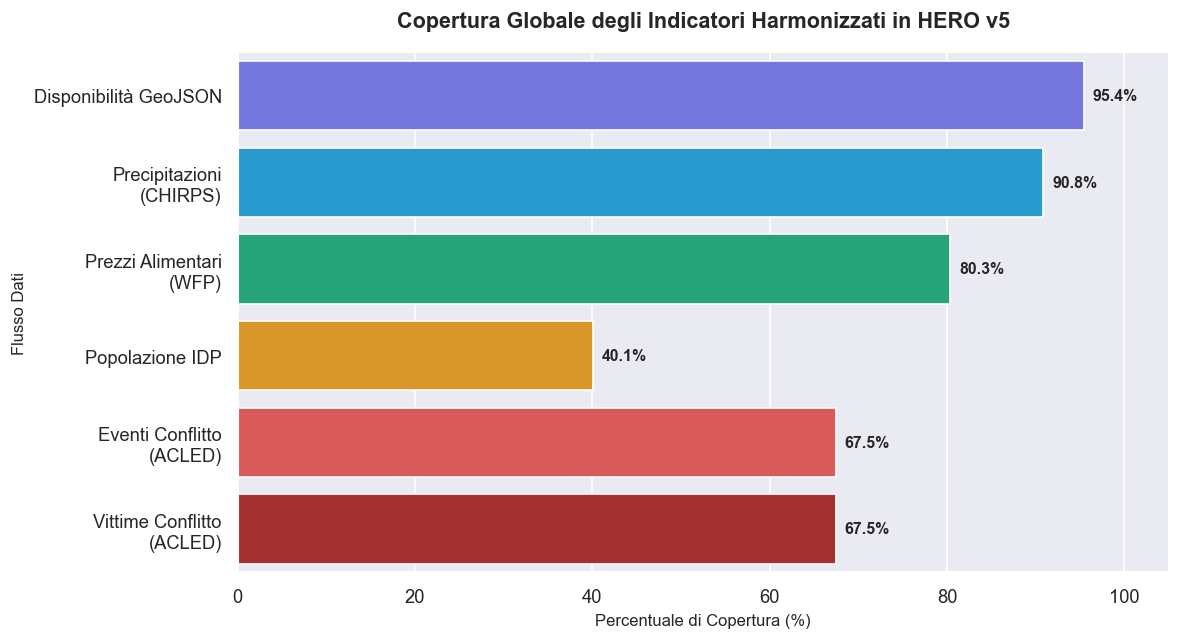

In [4]:
plt.figure(figsize=(10, 5.5))
cov_series = df[indicators].mean() * 100
cov_df = cov_series.reset_index()
cov_df.columns = ['Indicator', 'Coverage']
cov_df['Indicator'] = [l.replace(' (', '\n(') for l in labels] # split labels for layout

colors = ['#6366f1', '#0ea5e9', '#10b981', '#f59e0b', '#ef4444', '#b91c1c']
ax = sns.barplot(x='Coverage', y='Indicator', data=cov_df, palette=colors)
plt.xlim(0, 105)
plt.title("Copertura Globale degli Indicatori Harmonizzati in HERO v5", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Percentuale di Copertura (%)", fontsize=10)
plt.ylabel("Flusso Dati", fontsize=10)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", (p.get_width() + 1, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9.5, fontweight='semibold')

plt.tight_layout()
plt.savefig("plots/overall_coverage.png", dpi=150)
plt.show()

## 4. Evoluzione Temporale della Copertura

Analizziamo come varia la disponibilità dei flussi dati nel corso degli anni.

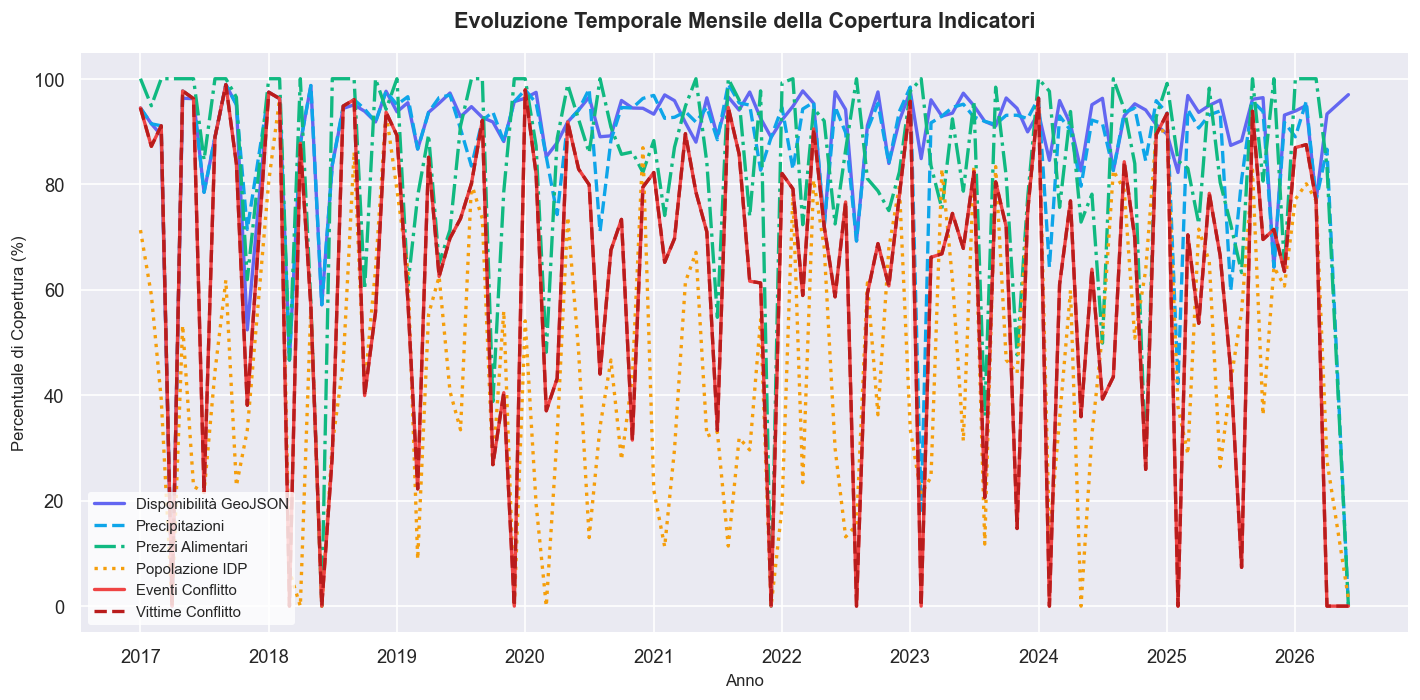

In [5]:
df['year_month'] = pd.to_datetime(df['From']).dt.to_period('M')
monthly_cov = df.groupby('year_month')[indicators].mean() * 100
monthly_cov.index = monthly_cov.index.to_timestamp()

plt.figure(figsize=(12, 6))
line_styles = ['-', '--', '-.', ':', '-', '--']
line_colors = ['#6366f1', '#0ea5e9', '#10b981', '#f59e0b', '#ef4444', '#b91c1c']

for col, label, style, color in zip(indicators, labels, line_styles, line_colors):
    plt.plot(monthly_cov.index, monthly_cov[col], label=label.split(' (')[0], linestyle=style, color=color, linewidth=2)
    
plt.ylim(-5, 105)
plt.title("Evoluzione Temporale Mensile della Copertura Indicatori", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Anno", fontsize=10)
plt.ylabel("Percentuale di Copertura (%)", fontsize=10)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', fontsize=9)
plt.tight_layout()
plt.savefig("plots/temporal_coverage_trends.png", dpi=150)
plt.show()

## 5. Matrice Spazio-Temporale di Completezza Dati per Paese

Valutiamo il livello complessivo di disponibilità (media di tutti i 6 indicatori) per ciascun paese nel tempo.

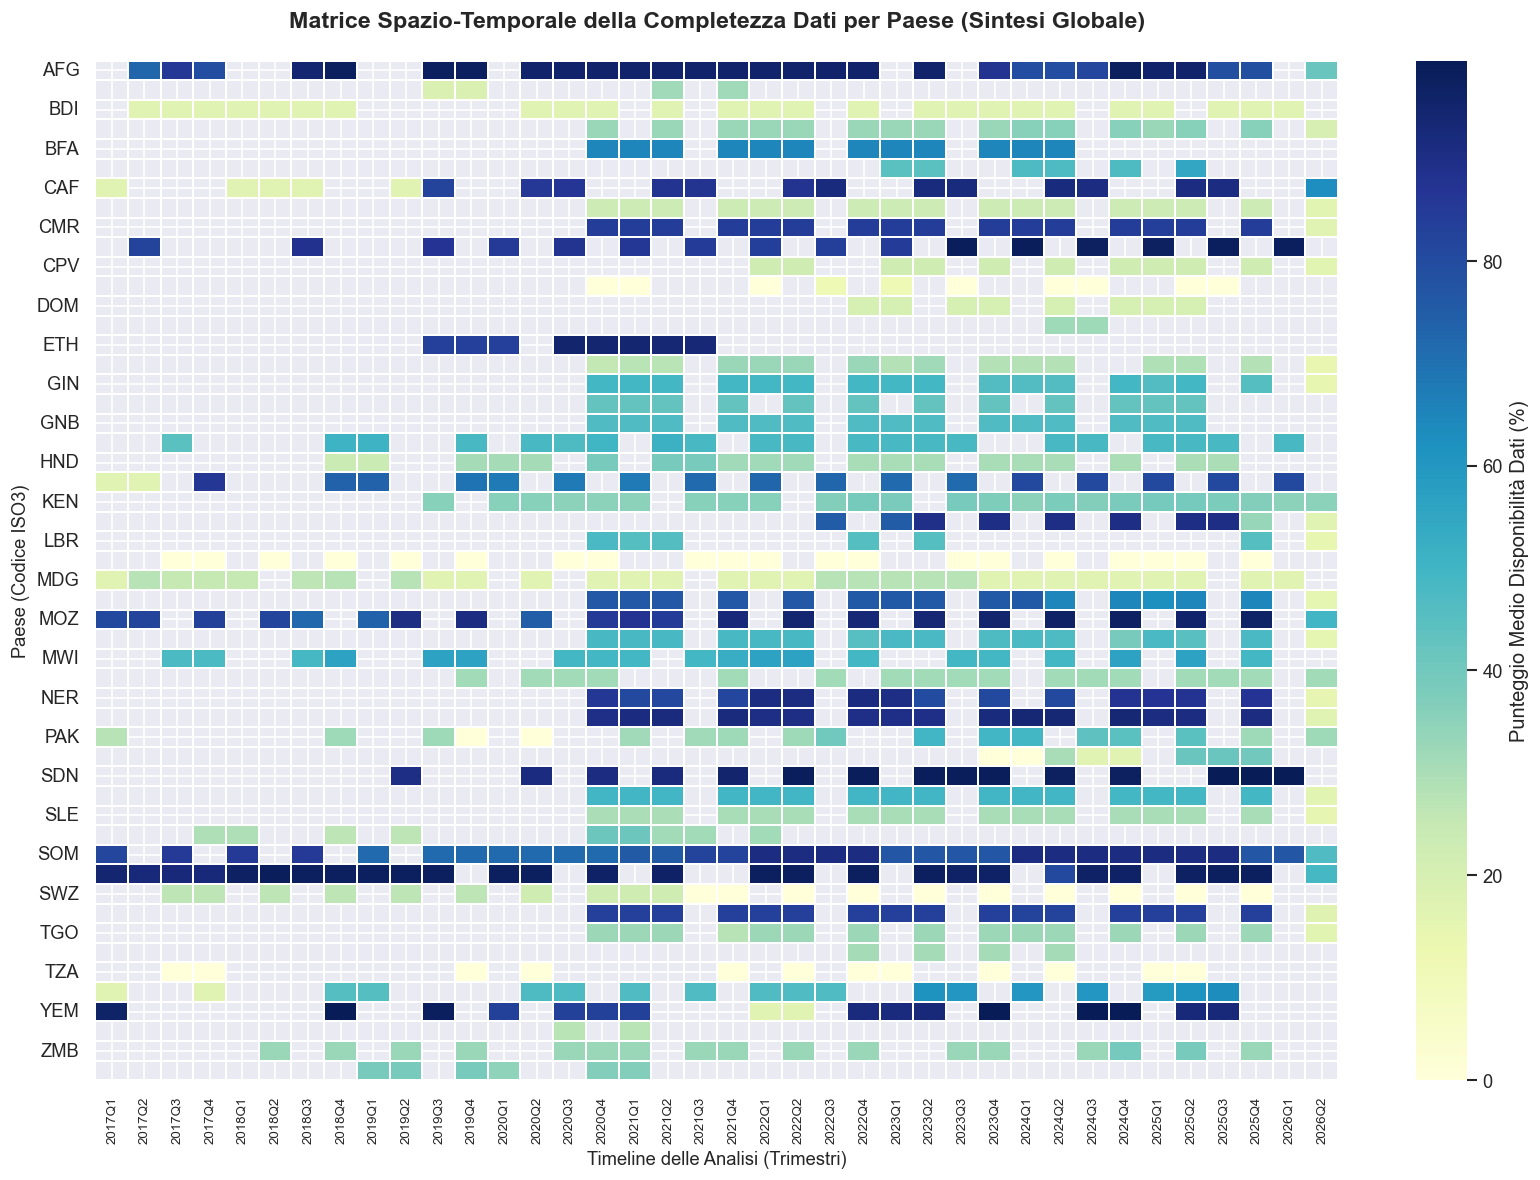

In [6]:
# Calcola un punteggio medio di disponibilità (0-100%) per ciascuna riga
df['avail_score'] = df[indicators].sum(axis=1) / len(indicators) * 100
df['year_quarter'] = pd.to_datetime(df['From']).dt.to_period('Q')
country_time = df.pivot_table(index='Country', columns='year_quarter', values='avail_score', aggfunc='mean')

# Ordiniamo i paesi in ordine alfabetico
country_order = sorted(df['Country'].unique())
country_time = country_time.loc[country_order]

# Pulizia delle date sull'asse X (formato YYYYQ1/Q2/Q3/Q4)
country_time.columns = [str(q) for q in country_time.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(country_time, cmap='YlGnBu', cbar_kws={'label': 'Punteggio Medio Disponibilità Dati (%)'},
            linewidths=0.1, linecolor='white')
plt.title("Matrice Spazio-Temporale della Completezza Dati per Paese (Sintesi Globale)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Timeline delle Analisi (Trimestri)", fontsize=11)
plt.ylabel("Paese (Codice ISO3)", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig("plots/spacetime_completeness_heatmap.png", dpi=150)
plt.show()


## 6. Matrici Spazio-Temporali Specializzate per Feature (Trimestrale)

Generiamo e salviamo la stessa matrice spazio-temporale per ciascuno dei sei indicatori individuali a frequenza trimestrale per analizzare dove risiedono i dati mancanti per ciascuna feature.

Salvato plot per Disponibilità GeoJSON in plots/spacetime_has_geojson_completeness_heatmap.png


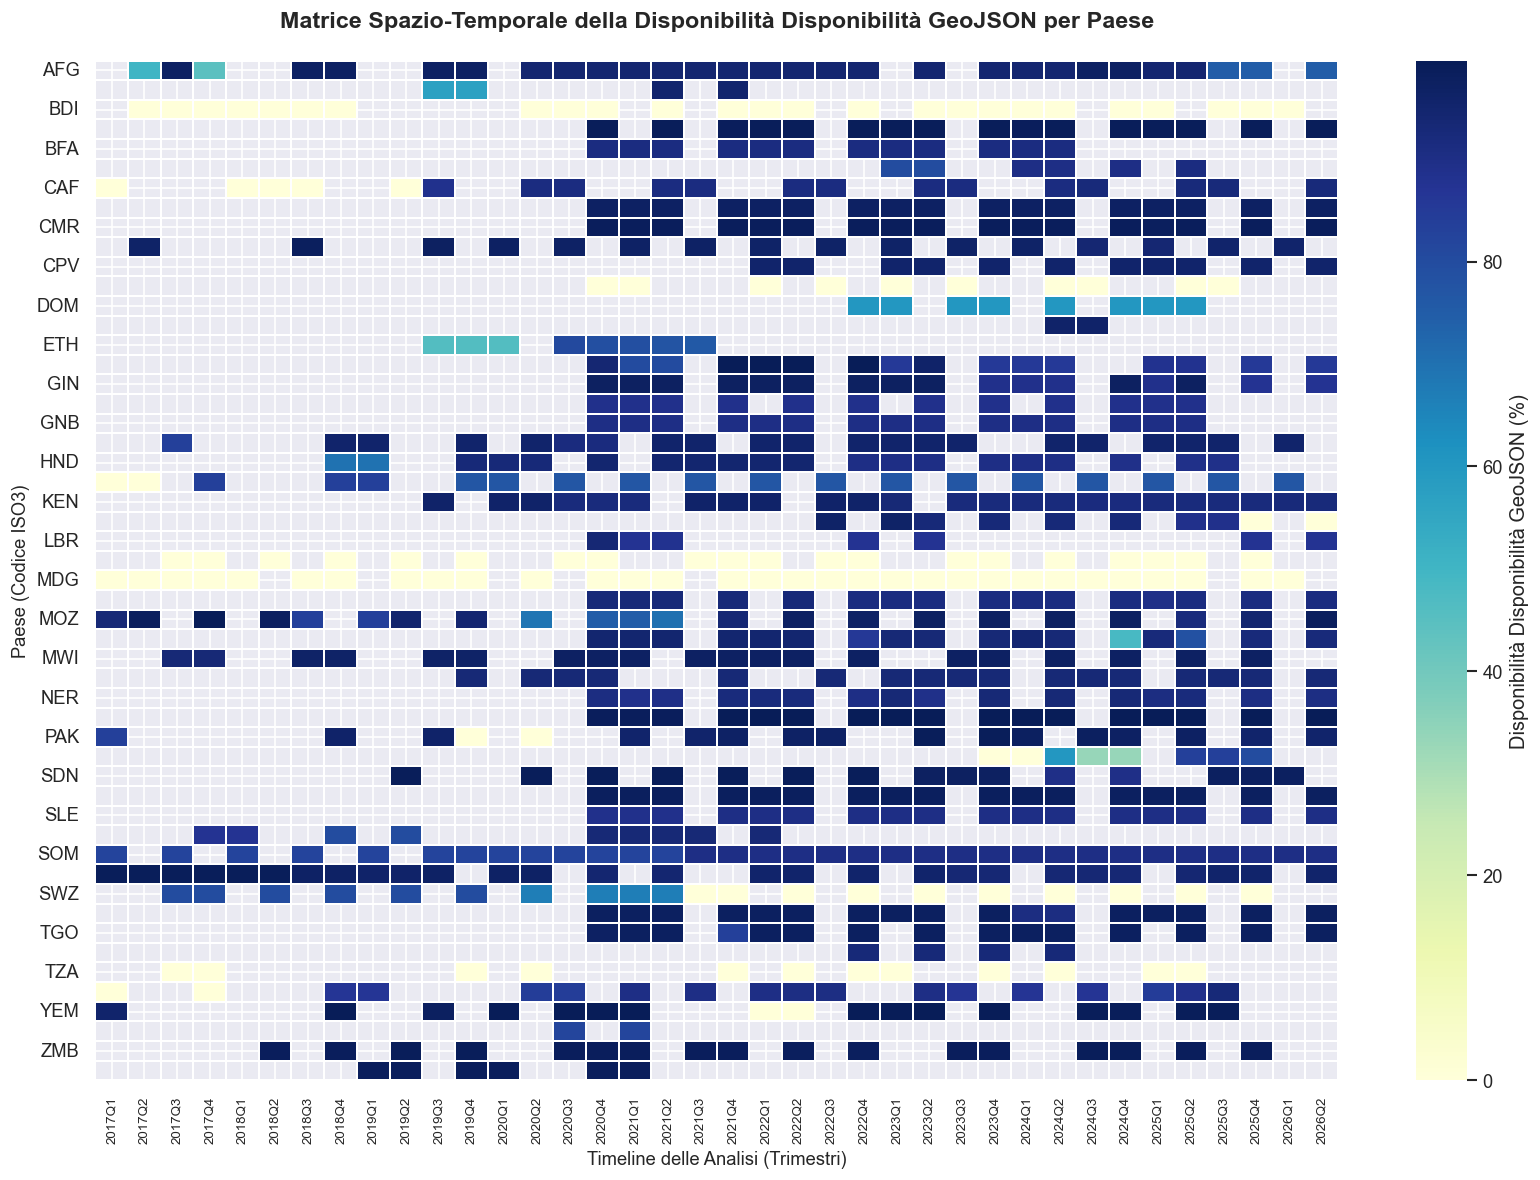

Salvato plot per Precipitazioni (CHIRPS) in plots/spacetime_has_rainfall_completeness_heatmap.png


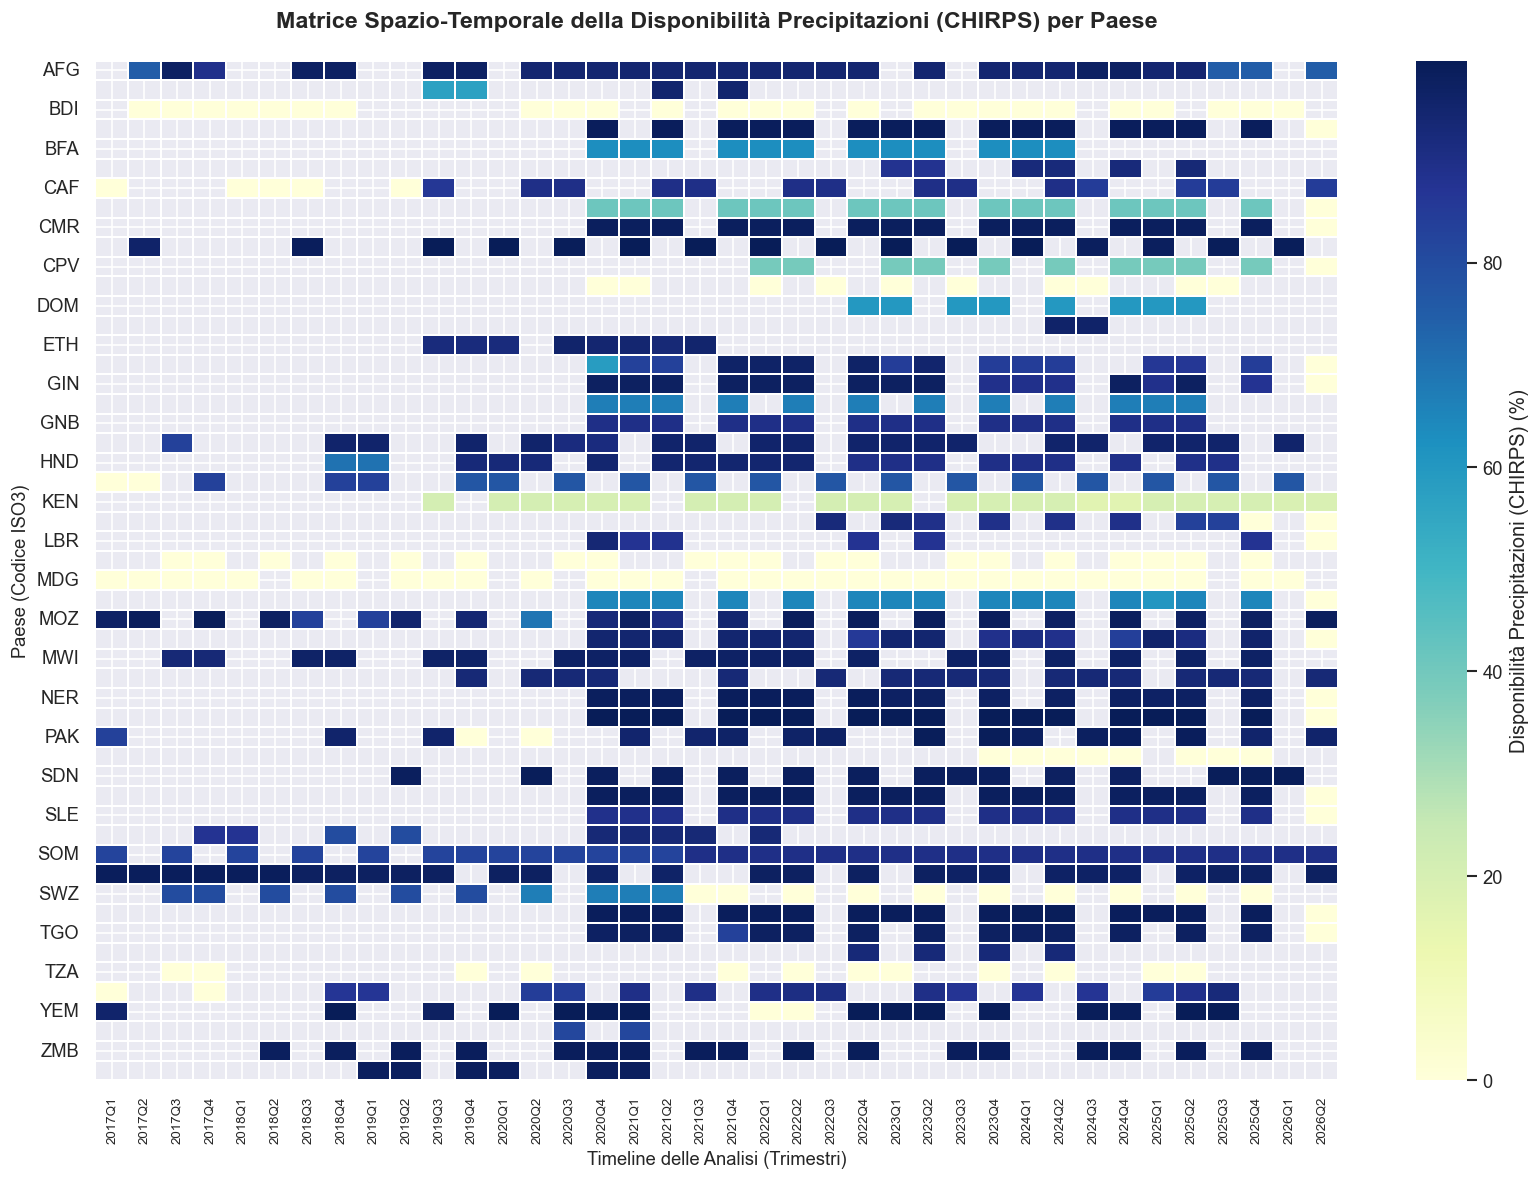

Salvato plot per Prezzi Alimentari (WFP) in plots/spacetime_has_wfp_completeness_heatmap.png


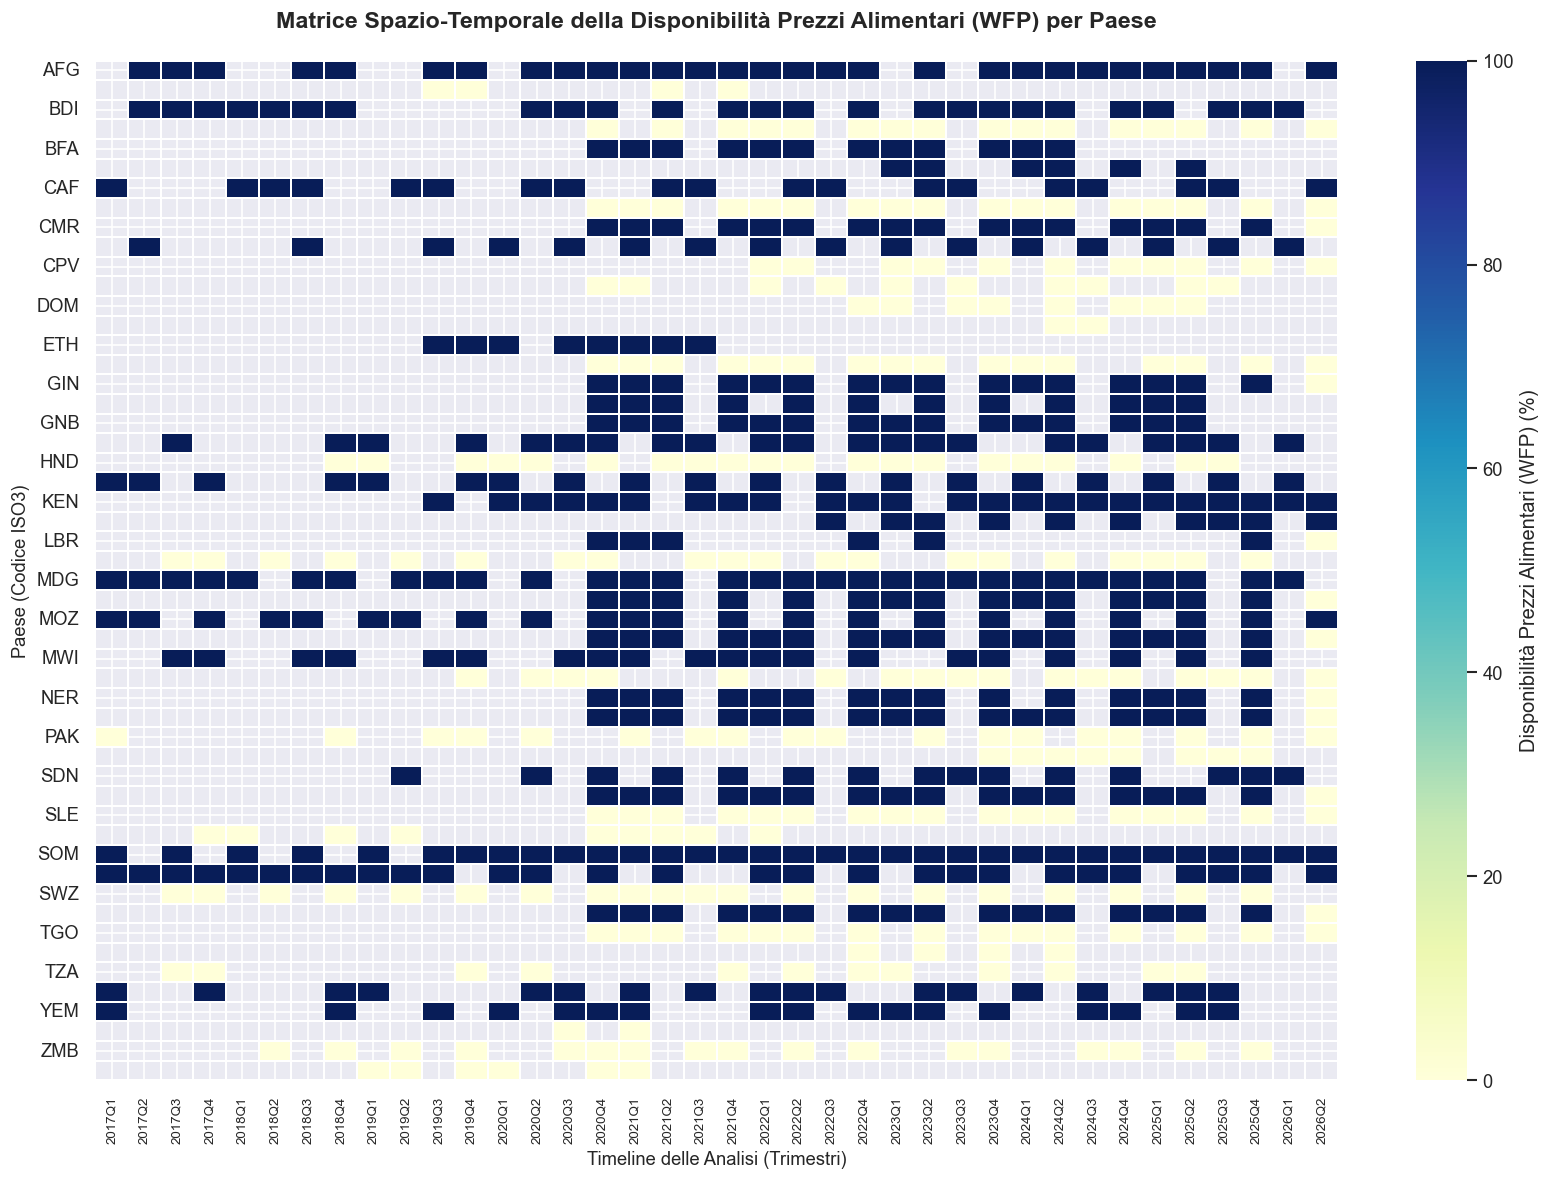

Salvato plot per Popolazione IDP in plots/spacetime_has_idp_completeness_heatmap.png


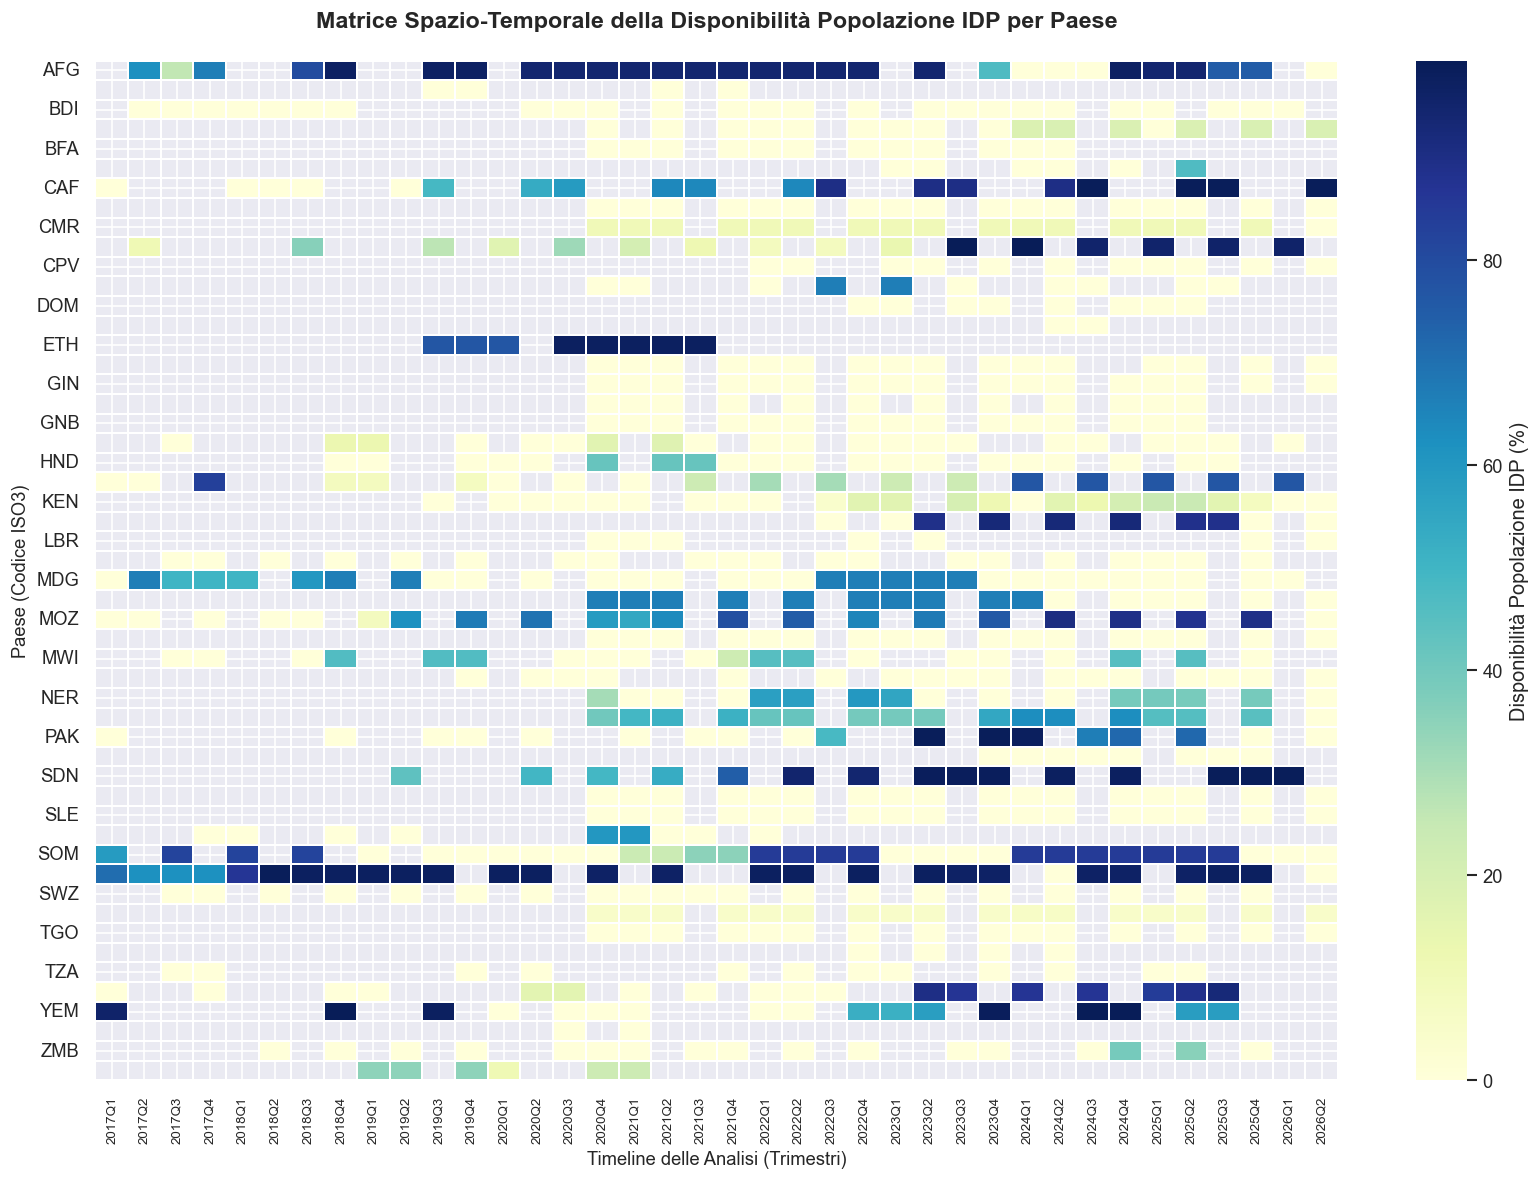

Salvato plot per Eventi Conflitto (ACLED) in plots/spacetime_has_acled_events_completeness_heatmap.png


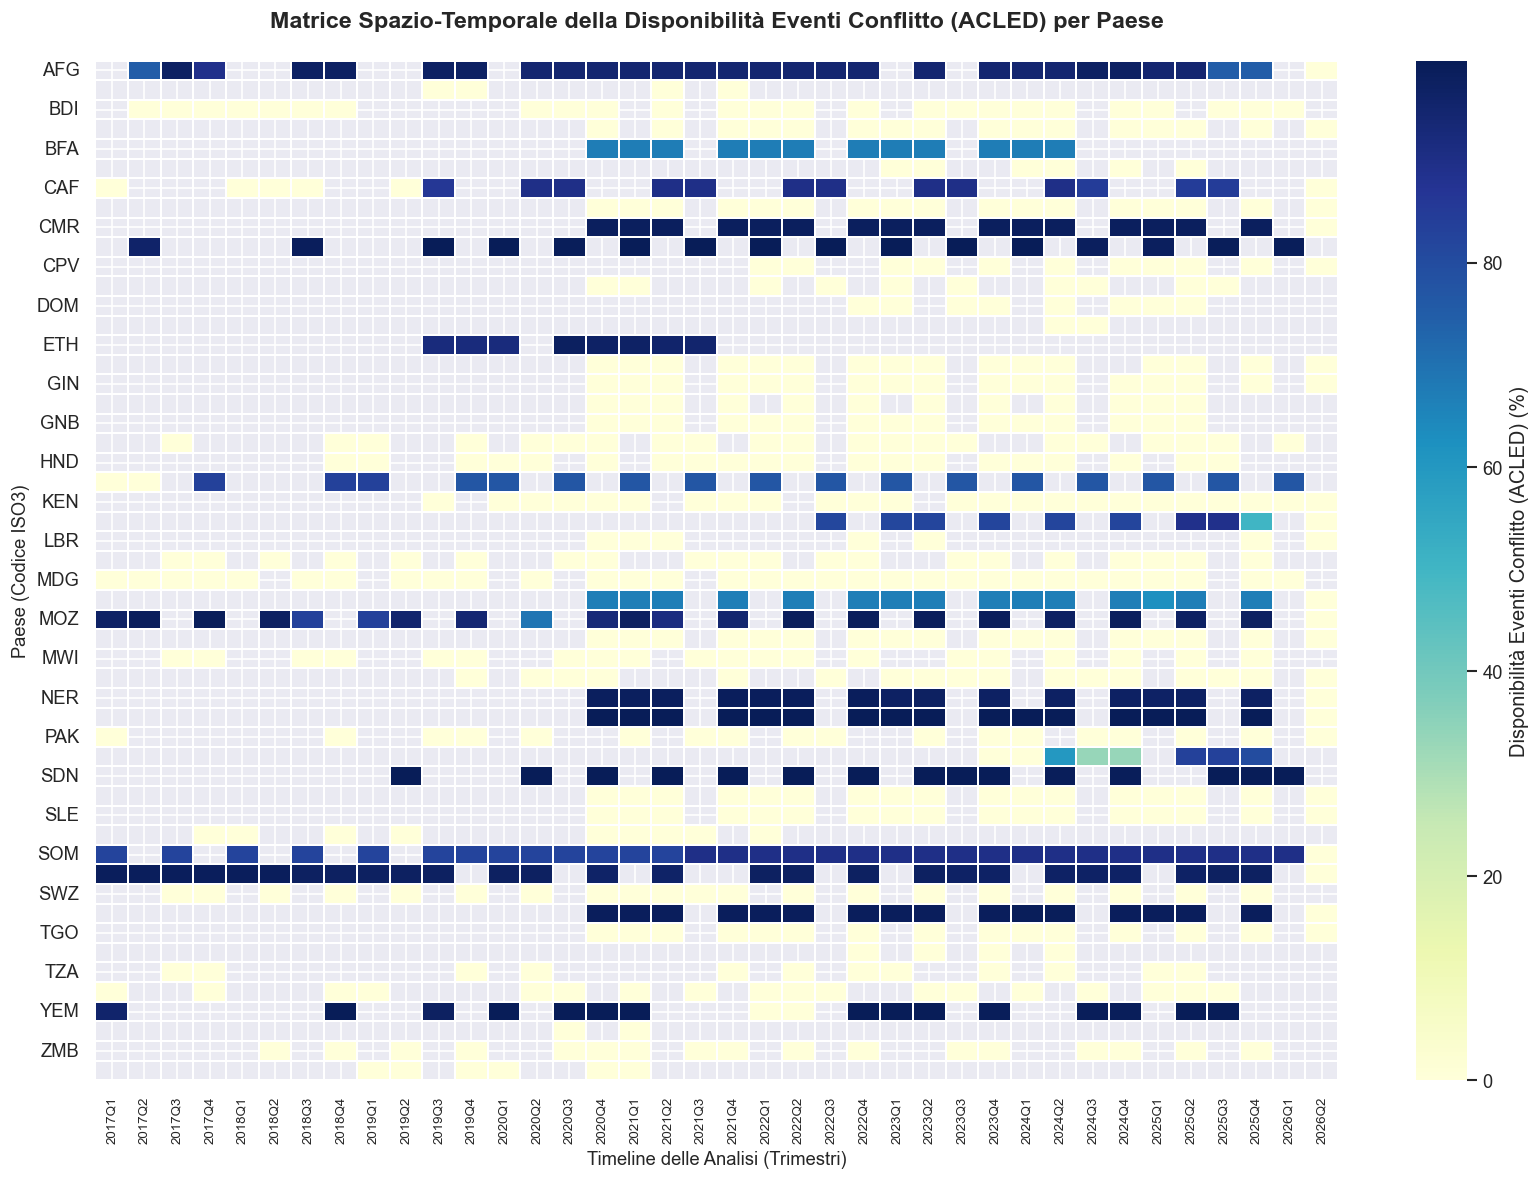

Salvato plot per Vittime Conflitto (ACLED) in plots/spacetime_has_acled_fatalities_completeness_heatmap.png


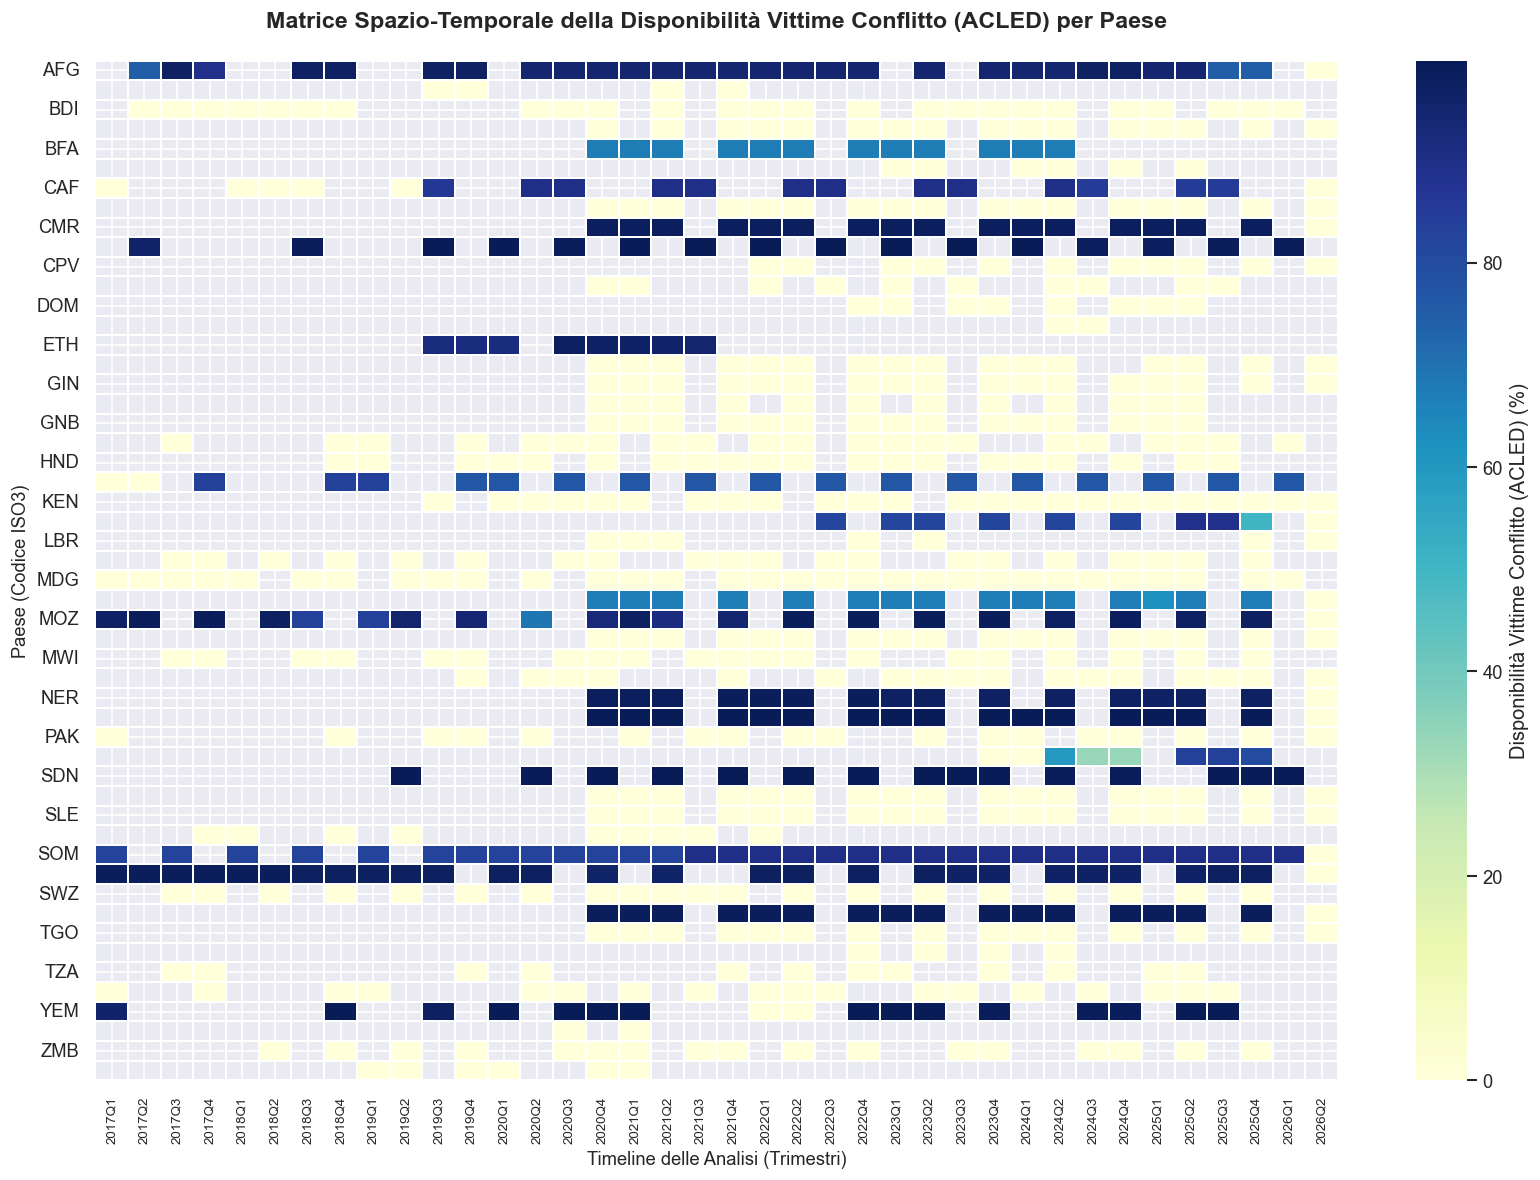

In [7]:
# Creiamo i grafici per ciascuna feature separatamente, con ordinamento alfabetico dei paesi e frequenza trimestrale
for ind, label in zip(indicators, labels):
    feature_time = df.pivot_table(index='Country', columns='year_quarter', values=ind, aggfunc='mean')
    # Moltiplichiamo per 100 per avere la percentuale (0-100%)
    feature_time = feature_time * 100
    
    # Ordiniamo i paesi in ordine alfabetico
    feature_time = feature_time.loc[country_order]
    
    # Pulizia delle date sull'asse X
    feature_time.columns = [str(q) for q in feature_time.columns]
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(feature_time, cmap='YlGnBu', cbar_kws={'label': f'Disponibilità {label} (%)'},
                linewidths=0.1, linecolor='white')
    plt.title(f"Matrice Spazio-Temporale della Disponibilità {label} per Paese", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Timeline delle Analisi (Trimestri)", fontsize=11)
    plt.ylabel("Paese (Codice ISO3)", fontsize=11)
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    file_name = f"plots/spacetime_{ind}_completeness_heatmap.png"
    plt.savefig(file_name, dpi=150)
    print(f"Salvato plot per {label} in {file_name}")
    plt.show()


## 7. Analisi Duale dell'Accoppiamento (Dati Sorgente Persi/Scollegati)

L'analisi duale risponde alla domanda: quanti dei record dei dataset sorgente esterni (prezzi alimentari WFP, precipitazioni CHIRPS, confini GeoJSON) non sono stati associati ad alcuna riga IPC e sono andati perduti o scartati nel processo di allineamento?

In [8]:
import os
import re
import geopandas as gpd

# 1. Caricamento dati sorgente
wfp_path = Path("data/wfp_with_pcodes.parquet")
rain_path = Path("../rainfall/data/clean_rainfall/rainfall_monthly.parquet")
ipc_base_path = Path("../ipc_rain_conflict_idp.parquet")

df_wfp_src = pd.read_parquet(wfp_path)
df_rain_src = pd.read_parquet(rain_path)
df_ipc_src = pd.read_parquet(ipc_base_path)

# Funzione per normalizzare i nomi per il matching
def normalize_name(name):
    if pd.isna(name):
        return ""
    name_str = str(name).lower().strip()
    name_str = re.sub(r'[^a-z0-9\s]', '', name_str)
    name_str = re.sub(r'\s+', ' ', name_str)
    return name_str.strip()

# Esplosione temporale in mesi dell'IPC per determinare gli accoppiamenti
df_ipc_src['date_from'] = pd.to_datetime(df_ipc_src['From'])
df_ipc_src['date_to'] = pd.to_datetime(df_ipc_src['To'])

for col in ["adm1_pcode", "adm2_pcode"]:
    df_ipc_src[col] = df_ipc_src[col].fillna("").astype(str).str.strip()
    df_ipc_src.loc[df_ipc_src[col] == "nan", col] = ""

df_ipc_src["is_true_admin2"] = (
    (df_ipc_src["adm2_pcode"] != "") & 
    (df_ipc_src["adm1_pcode"] != "") & 
    (df_ipc_src["adm2_pcode"] != df_ipc_src["adm1_pcode"])
)

df_ipc_months = df_ipc_src.copy()
df_ipc_months['date'] = df_ipc_months.apply(
    lambda r: pd.date_range(start=r['date_from'], end=r['date_to'], freq='MS'),
    axis=1
)
df_ipc_months = df_ipc_months.explode('date').dropna(subset=['date'])
df_ipc_months['date'] = pd.to_datetime(df_ipc_months['date'])
df_ipc_months['norm_adm1'] = df_ipc_months['Level 1'].apply(normalize_name)

# --- ANALISI WFP DUALE ---
df_wfp_src['date'] = pd.to_datetime(df_wfp_src['date'])
df_wfp_src['norm_adm1'] = df_wfp_src['adm1_name'].apply(normalize_name)

# Match Admin2
ipc_a2 = df_ipc_months[df_ipc_months['is_true_admin2']][['Country', 'adm2_pcode', 'date']].drop_duplicates()
ipc_a2['matched_a2'] = True
df_wfp_m = df_wfp_src.merge(ipc_a2, left_on=['ISO3', 'adm2_pcode', 'date'], right_on=['Country', 'adm2_pcode', 'date'], how='left')
df_wfp_m = df_wfp_m.drop(columns=['Country'], errors='ignore')

# Match Admin1 Code
ipc_a1 = df_ipc_months[['Country', 'adm1_pcode', 'date']].drop_duplicates()
ipc_a1['matched_a1'] = True
df_wfp_m = df_wfp_m.merge(ipc_a1, left_on=['ISO3', 'adm1_pcode', 'date'], right_on=['Country', 'adm1_pcode', 'date'], how='left')
df_wfp_m = df_wfp_m.drop(columns=['Country'], errors='ignore')

# Match Admin1 Name
ipc_a1_name = df_ipc_months[['Country', 'norm_adm1', 'date']].drop_duplicates()
ipc_a1_name['matched_a1_name'] = True
df_wfp_m = df_wfp_m.merge(ipc_a1_name, left_on=['ISO3', 'norm_adm1', 'date'], right_on=['Country', 'norm_adm1', 'date'], how='left')
df_wfp_m = df_wfp_m.drop(columns=['Country'], errors='ignore')

# Match National
ipc_nat = df_ipc_months[['Country', 'date']].drop_duplicates()
ipc_nat['matched_nat'] = True
df_wfp_m = df_wfp_m.merge(ipc_nat, left_on=['ISO3', 'date'], right_on=['Country', 'date'], how='left')
df_wfp_m = df_wfp_m.drop(columns=['Country'], errors='ignore')

df_wfp_m['match_level'] = 'Unmatched'
df_wfp_m.loc[df_wfp_m['matched_nat'] == True, 'match_level'] = 'National'
df_wfp_m.loc[df_wfp_m['matched_a1_name'] == True, 'match_level'] = 'Admin1_Name'
df_wfp_m.loc[df_wfp_m['matched_a1'] == True, 'match_level'] = 'Admin1_Code'
df_wfp_m.loc[df_wfp_m['matched_a2'] == True, 'match_level'] = 'Admin2'

# --- ANALISI RAINFALL DUALE ---
df_rain_src['date'] = pd.to_datetime(df_rain_src['date'])
df_rain_src['month_start'] = df_rain_src['date'].dt.to_period('M').dt.to_timestamp()

df_rain_m = df_rain_src.merge(ipc_a2, left_on=['ISO3', 'PCODE', 'month_start'], right_on=['Country', 'adm2_pcode', 'date'], how='left')
df_rain_m = df_rain_m.drop(columns=['Country', 'date_y'], errors='ignore').rename(columns={'date_x': 'date'})

df_rain_m = df_rain_m.merge(ipc_a1, left_on=['ISO3', 'PCODE', 'month_start'], right_on=['Country', 'adm1_pcode', 'date'], how='left')
df_rain_m = df_rain_m.drop(columns=['Country', 'date_y'], errors='ignore').rename(columns={'date_x': 'date'})

df_rain_m = df_rain_m.merge(ipc_nat, left_on=['ISO3', 'month_start'], right_on=['Country', 'date'], how='left')
df_rain_m = df_rain_m.drop(columns=['Country', 'date_y'], errors='ignore').rename(columns={'date_x': 'date'})

df_rain_m['match_level'] = 'Unmatched'
df_rain_m.loc[df_rain_m['matched_nat'] == True, 'match_level'] = 'National'
df_rain_m.loc[(df_rain_m['matched_a1'] == True) & (df_rain_m['adm_level'] == 1), 'match_level'] = 'Admin1'
df_rain_m.loc[(df_rain_m['matched_a2'] == True) & (df_rain_m['adm_level'] == 2), 'match_level'] = 'Admin2'

# --- ANALISI GEOJSON DUALE ---
boundary_pcodes_adm1 = set()
boundary_pcodes_adm2 = set()

def standardize_pcode_col(gdf, level):
    for col in gdf.columns:
        if f"adm{level}" in str(col).lower() and "pco" in str(col).lower():
            return gdf.rename(columns={col: f"adm{level}_pcode"})
    for col in gdf.columns:
        if "pcode" in str(col).lower() and str(level) in str(col).lower():
            return gdf.rename(columns={col: f"adm{level}_pcode"})
    return gdf

boundaries_dir = Path("data/boundaries")
for folder in boundaries_dir.glob("*"):
    if folder.is_dir():
        for f in folder.rglob("*.geojson"):
            if "adm1" in f.name.lower() or "admin1" in f.name.lower():
                try:
                    gdf = gpd.read_file(f)
                    gdf = standardize_pcode_col(gdf, 1)
                    if "adm1_pcode" in gdf.columns:
                        boundary_pcodes_adm1.update(gdf["adm1_pcode"].dropna().unique())
                except Exception:
                    pass
            if "adm2" in f.name.lower() or "admin2" in f.name.lower():
                try:
                    gdf = gpd.read_file(f)
                    gdf = standardize_pcode_col(gdf, 2)
                    if "adm2_pcode" in gdf.columns:
                        boundary_pcodes_adm2.update(gdf["adm2_pcode"].dropna().unique())
                except Exception:
                    pass

boundary_pcodes = boundary_pcodes_adm1.union(boundary_pcodes_adm2)
ipc_pcodes = set(df_ipc_src['adm1_pcode'].unique()).union(set(df_ipc_src['adm2_pcode'].unique()))

wfp_matched_pct = (df_wfp_m['match_level'] != 'Unmatched').mean() * 100
rain_matched_pct = (df_rain_m['match_level'] != 'Unmatched').mean() * 100
geo_matched_pct = len(boundary_pcodes.intersection(ipc_pcodes)) / max(1, len(boundary_pcodes)) * 100

print("Tassi di accoppiamento duale globale (Sorgenti -> IPC):")
print(f"  - Prezzi Alimentari WFP: {wfp_matched_pct:.2f}% Accoppiati | {100 - wfp_matched_pct:.2f}% Persi (Unmatched)")
print(f"  - Precipitazioni Rainfall: {rain_matched_pct:.2f}% Accoppiati | {100 - rain_matched_pct:.2f}% Persi (Unmatched)")
print(f"  - Confini GeoJSON PCodes: {geo_matched_pct:.2f}% Accoppiati | {100 - geo_matched_pct:.2f}% Inutilizzati (Unmatched)")

Tassi di accoppiamento duale globale (Sorgenti -> IPC):
  - Prezzi Alimentari WFP: 23.67% Accoppiati | 76.33% Persi (Unmatched)
  - Precipitazioni Rainfall: 44.68% Accoppiati | 55.32% Persi (Unmatched)
  - Confini GeoJSON PCodes: 54.05% Accoppiati | 45.95% Inutilizzati (Unmatched)


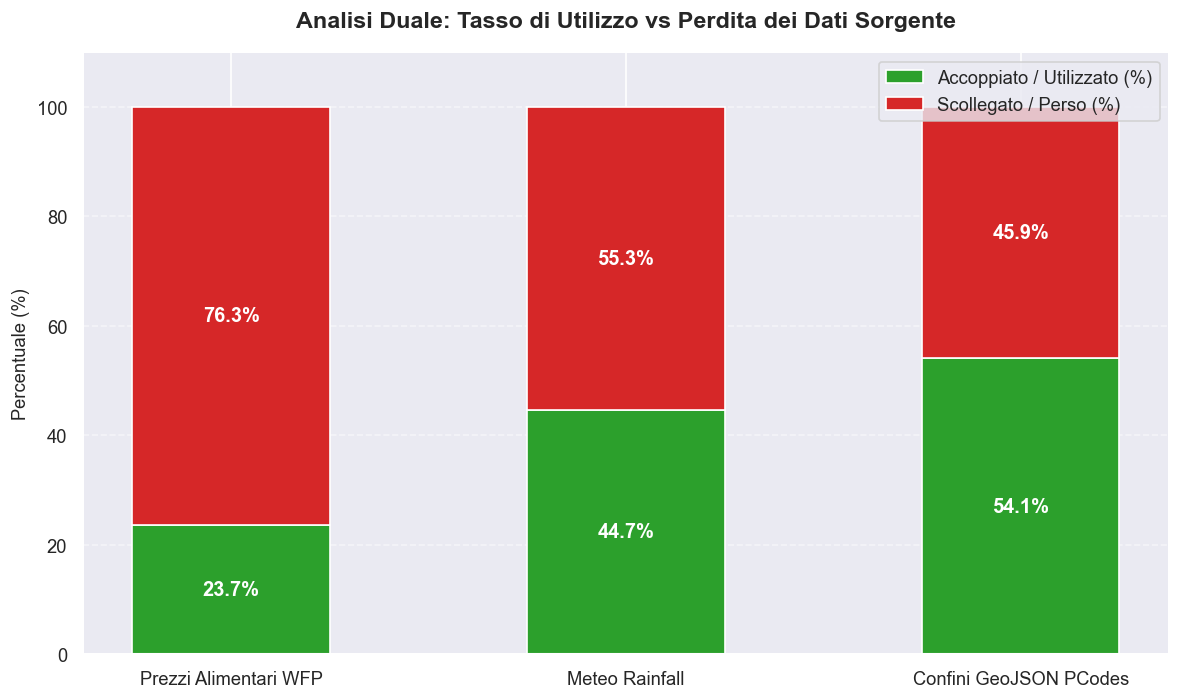

In [9]:
# Grafico a barre impilate per visualizzare i tassi di accoppiamento e perdita
categories = ['Prezzi Alimentari WFP', 'Meteo Rainfall', 'Confini GeoJSON PCodes']
matched_vals = [wfp_matched_pct, rain_matched_pct, geo_matched_pct]
unmatched_vals = [100 - wfp_matched_pct, 100 - rain_matched_pct, 100 - geo_matched_pct]

plt.figure(figsize=(10, 6))
bar_width = 0.5
bars_matched = plt.bar(categories, matched_vals, label='Accoppiato / Utilizzato (%)', color='#2ca02c', width=bar_width)
bars_unmatched = plt.bar(categories, unmatched_vals, bottom=matched_vals, label='Scollegato / Perso (%)', color='#d62728', width=bar_width)

# Aggiunta etichette sui segmenti delle barre
for bar_m, bar_u in zip(bars_matched, bars_unmatched):
    y_m = bar_m.get_height()
    y_u = bar_u.get_height()
    if y_m > 5:
        plt.text(bar_m.get_x() + bar_m.get_width()/2, y_m / 2, f"{y_m:.1f}%", 
                 ha='center', va='center', color='white', fontweight='bold')
    if y_u > 5:
        plt.text(bar_u.get_x() + bar_u.get_width()/2, y_m + y_u / 2, f"{y_u:.1f}%", 
                 ha='center', va='center', color='white', fontweight='bold')

plt.title("Analisi Duale: Tasso di Utilizzo vs Perdita dei Dati Sorgente", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Percentuale (%)", fontsize=11)
plt.ylim(0, 110)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/dual_source_matching_rates.png", dpi=150)
plt.show()


## 6. Confronto della Risoluzione Spaziale (Livello Admin1 vs Admin2)

Verifichiamo se la disponibilità delle informazioni differisce in base al livello amministrativo.

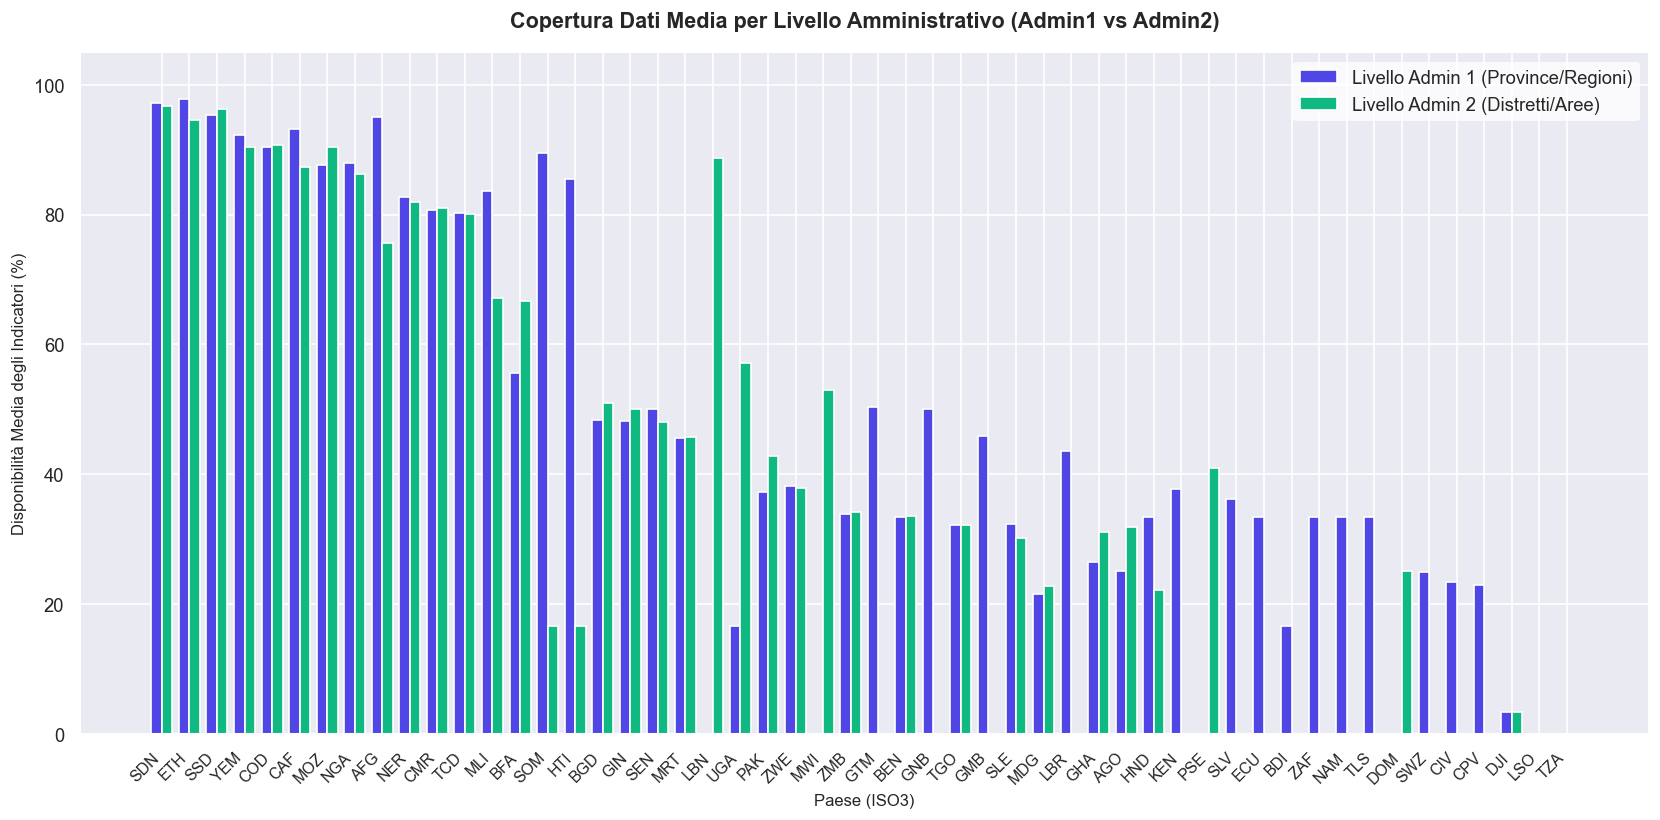

In [10]:
# Calcoliamo la copertura media degli indicatori per livello amministrativo per ciascun paese
admin_coverage = df.groupby(['Country', 'admin_level'])[indicators].mean().mean(axis=1) * 100
admin_coverage = admin_coverage.unstack().fillna(0)

# Ordina per la media complessiva del paese
admin_coverage['mean'] = admin_coverage.mean(axis=1)
admin_coverage = admin_coverage.sort_values(by='mean', ascending=False).drop(columns='mean')

plt.figure(figsize=(14, 7))
x = np.arange(len(admin_coverage))
width = 0.38

plt.bar(x - width/2, admin_coverage[1], width, label='Livello Admin 1 (Province/Regioni)', color='#4f46e5')
plt.bar(x + width/2, admin_coverage[2], width, label='Livello Admin 2 (Distretti/Aree)', color='#10b981')

plt.title("Copertura Dati Media per Livello Amministrativo (Admin1 vs Admin2)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Paese (ISO3)", fontsize=10)
plt.ylabel("Disponibilità Media degli Indicatori (%)", fontsize=10)
plt.xticks(x, admin_coverage.index, rotation=45, ha='right', fontsize=9.5)
plt.ylim(0, 105)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.savefig("plots/admin_level_coverage.png", dpi=150)
plt.show()